# Mechanical Systems Modeling, Simulation and Control

This notebook covers translational, rotational, coupled, classical, state-space, digital, nonlinear and robust-control analysis.

### Included
Transfer functions, state-space, step/impulse/ramp, transient metrics, steady-state error, system type, \(K_p,K_v,K_a\), pole-zero maps, Routh-Hurwitz, root locus, Bode/Nyquist/Nichols, margins, resonance, lead/lag/lead-lag, P/PI/PD/PID, derivative filtering, anti-windup, feedforward, cascade, sensitivity, robustness, controllability/observability, canonical forms, state feedback, \(N_{\text{bar}}\), observer, LQR, Kalman/LQG, digital control, Jury stability, phase-plane, Jacobian linearization, saturation, deadband, backlash, friction, rotational systems, gears and modal analysis.

## Governing model

\[
m\ddot x+b\dot x+kx=F(t),\qquad
G(s)=\frac{1}{ms^2+bs+k}
\]

\[
\omega_n=\sqrt{k/m},\qquad
\zeta=\frac{b}{2\sqrt{km}}
\]

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.linalg as la
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

try:
    import control as ct
    HAS_CONTROL = True
except Exception as e:
    HAS_CONTROL = False
    print("Install python-control with: pip install control")
    print(e)

In [8]:
# %pip install control

In [9]:
def stability_from_poles(poles, tol=1e-8):
    p=np.asarray(poles,dtype=complex)
    if np.any(np.real(p)>tol): return "UNSTABLE"
    if np.all(np.real(p)<-tol): return "ASYMPTOTICALLY STABLE"
    return "MARGINALLY STABLE"

def damping_label(zeta,tol=.02):
    if zeta < 0: return "UNSTABLE / NEGATIVE DAMPING"
    if abs(zeta)<1e-8: return "UNDAMPED"
    if zeta < 1-tol: return "UNDERDAMPED"
    if zeta <= 1+tol: return "CRITICALLY DAMPED (approximately)"
    return "OVERDAMPED"

def modal_label(poles):
    p=np.asarray(poles,dtype=complex)
    st=stability_from_poles(p)
    cp=[z for z in p if abs(np.imag(z))>1e-8]
    if cp:
        d=max(cp,key=lambda z:np.real(z))
        zeta=-np.real(d)/abs(d)
        if st=="UNSTABLE": return "OSCILLATORY UNSTABLE",st,zeta
        if zeta<.98: return "UNDERDAMPED",st,zeta
        if zeta<=1.02: return "CRITICALLY DAMPED-LIKE",st,zeta
        return "OVERDAMPED-LIKE",st,zeta
    return ("OVERDAMPED-LIKE / NON-OSCILLATORY" if st=="ASYMPTOTICALLY STABLE" else st),st,None

def metrics(t,y,final=None):
    t=np.asarray(t); y=np.asarray(y)
    if final is None: final=y[-1]
    peak_i=int(np.argmax(y)); peak=y[peak_i]
    overshoot=np.nan if abs(final)<1e-12 else max(0,(peak-final)/abs(final)*100)
    def cross(level):
        idx=np.where(y>=level)[0] if final>=0 else np.where(y<=level)[0]
        return t[idx[0]] if len(idx) else np.nan
    t10,t90=cross(.1*final),cross(.9*final)
    rise=t90-t10 if np.isfinite(t10) and np.isfinite(t90) else np.nan
    band=.02*max(abs(final),1e-12)
    out=np.where(np.abs(y-final)>band)[0]
    settle=0 if len(out)==0 else (t[out[-1]+1] if out[-1]<len(t)-1 else np.nan)
    return dict(rise_time=rise,settling_time=settle,peak_time=t[peak_i],overshoot_percent=overshoot,peak_value=peak)

def routh_table(coeffs):
    a=np.asarray(coeffs,float)
    n=len(a)-1; c=int(np.ceil((n+1)/2))
    R=np.zeros((n+1,c))
    R[0,:len(a[0::2])]=a[0::2]
    R[1,:len(a[1::2])]=a[1::2]
    eps=1e-9
    for i in range(2,n+1):
        if abs(R[i-1,0])<eps: R[i-1,0]=eps
        for j in range(c-1):
            R[i,j]=(R[i-1,0]*R[i-2,j+1]-R[i-2,0]*R[i-1,j+1])/R[i-1,0]
    s=np.sign(R[:,0]); changes=int(np.sum(s[:-1]*s[1:]<0))
    return R,changes

def jury_second_order(a):
    a0,a1,a2=map(float,a)
    cond={"|a2|<a0":abs(a2)<a0,"P(1)>0":a0+a1+a2>0,"P(-1)>0":a0-a1+a2>0}
    return cond,all(cond.values())

## Interactive damping and stability classification

In [ ]:
def mechanical_core(m=10,b=8,k=100,F=100):
    wn=np.sqrt(k/m); zeta=b/(2*np.sqrt(k*m))
    A=np.array([[0,1],[-k/m,-b/m]])
    p=np.linalg.eigvals(A)
    print("Response:",damping_label(zeta))
    print("Stability:",stability_from_poles(p))
    print("Poles:",p)
    print("Natural frequency:",wn)
    def f(t,y): x,v=y; return [v,(F-b*v-k*x)/m]
    t=np.linspace(0,12,1800); sol=solve_ivp(f,[0,12],[0,0],t_eval=t)
    print(metrics(t,sol.y[0],F/k))
    plt.figure(figsize=(9,4)); plt.plot(t,sol.y[0]); plt.axhline(F/k,ls="--"); plt.grid(True); plt.title(damping_label(zeta)); plt.show()
widgets.interact(mechanical_core,
    m=widgets.FloatSlider(value=10,min=1,max=50,step=1),
    b=widgets.FloatSlider(value=8,min=-40,max=150,step=1),
    k=widgets.FloatSlider(value=100,min=10,max=500,step=10),
    F=widgets.FloatSlider(value=100,min=0,max=500,step=10));

interactive(children=(FloatSlider(value=10.0, description='m', max=50.0, min=1.0, step=1.0), FloatSlider(value…

## Classical control analysis

Poles: [-0.4+3.13687743j -0.4-3.13687743j]
Zeros: []


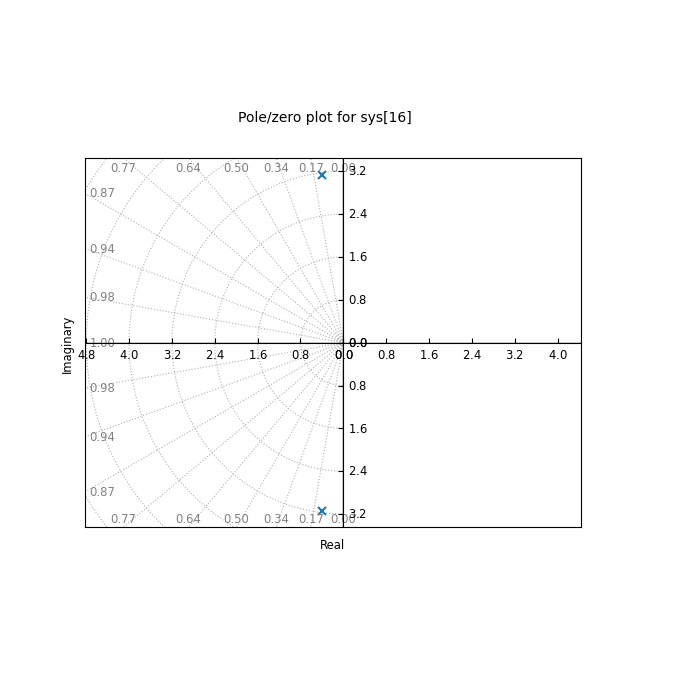

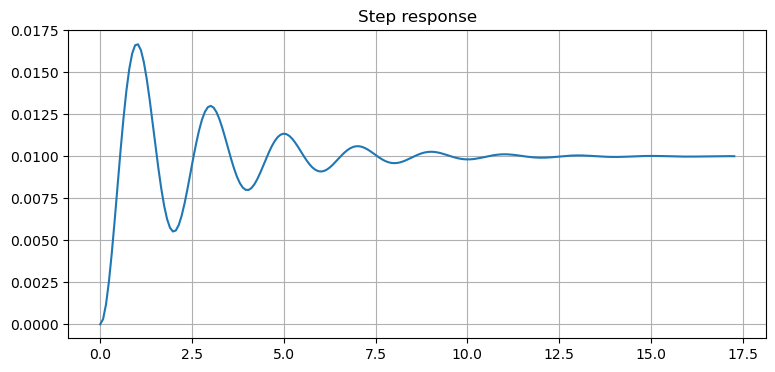

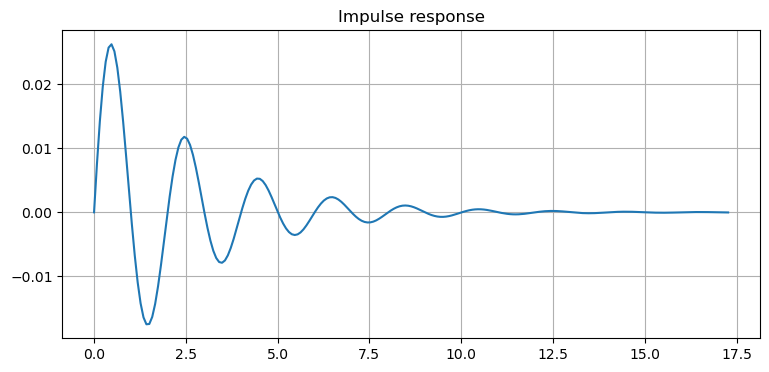

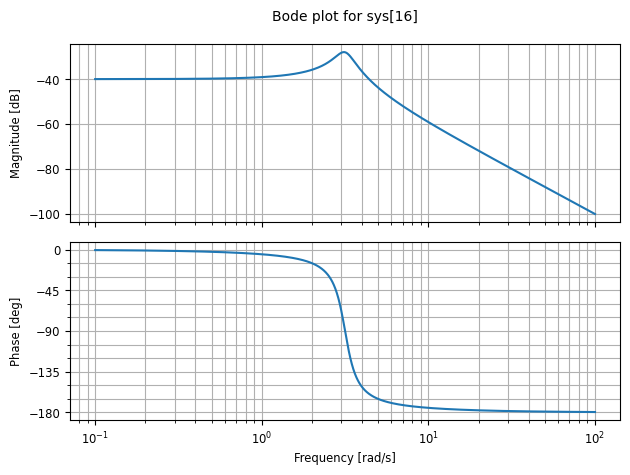

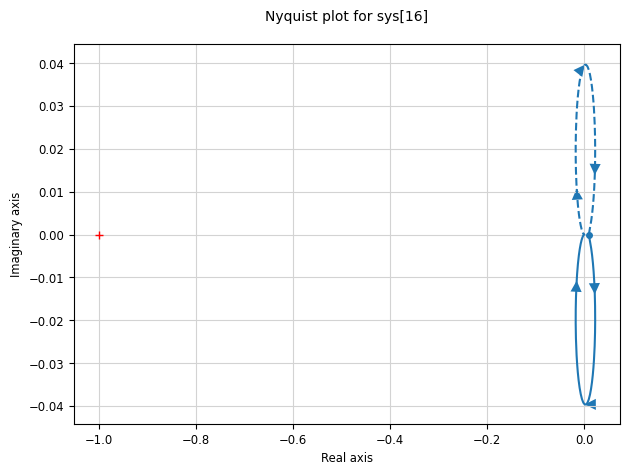

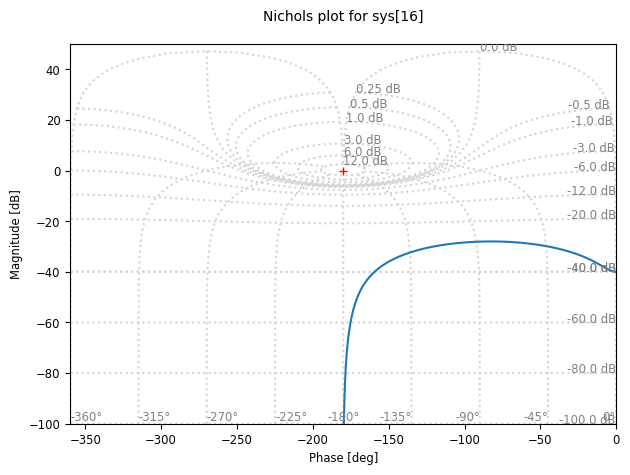

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


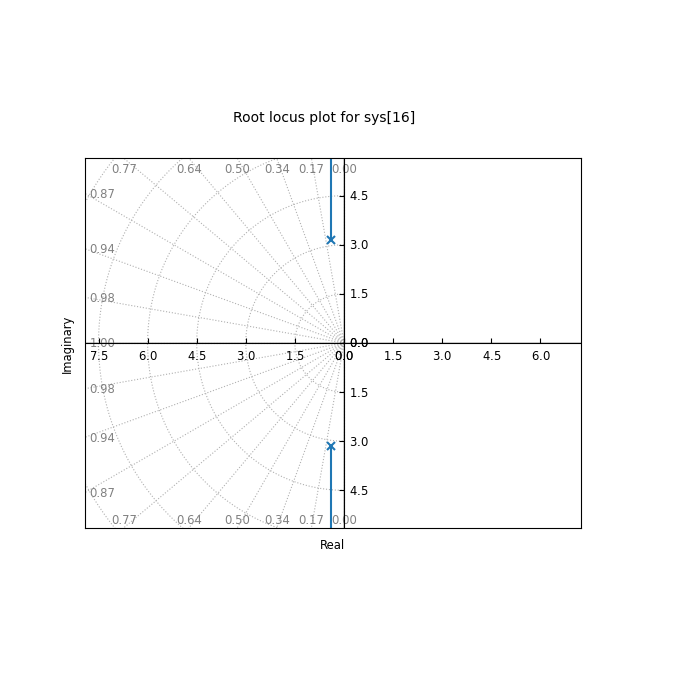

Margins (GM, PM, Wcg, Wcp): (inf, inf, nan, nan)
Bandwidth: 4.855993222974377


In [11]:
G=ct.tf([1],[10,8,100])

if HAS_CONTROL:
    print("Poles:",ct.poles(G))
    print("Zeros:",ct.zeros(G))
    ct.pzmap(G,grid=True); plt.show()
    t,y=ct.step_response(G); plt.figure(figsize=(9,4)); plt.plot(t,y); plt.grid(True); plt.title("Step response"); plt.show()
    t,y=ct.impulse_response(G); plt.figure(figsize=(9,4)); plt.plot(t,y); plt.grid(True); plt.title("Impulse response"); plt.show()
    ct.bode_plot(G,dB=True,grid=True); plt.show()
    ct.nyquist_plot(G); plt.grid(True); plt.show()
    try:
        ct.nichols_plot(G,grid=True); plt.show()
    except Exception as e:
        print("Nichols:",e)
    ct.root_locus_plot(G,grid=True); plt.show()
    print("Margins (GM, PM, Wcg, Wcp):",ct.margin(G))
    try: print("Bandwidth:",ct.bandwidth(G))
    except Exception as e: print("Bandwidth:",e)

## Ramp response, system type and static error constants

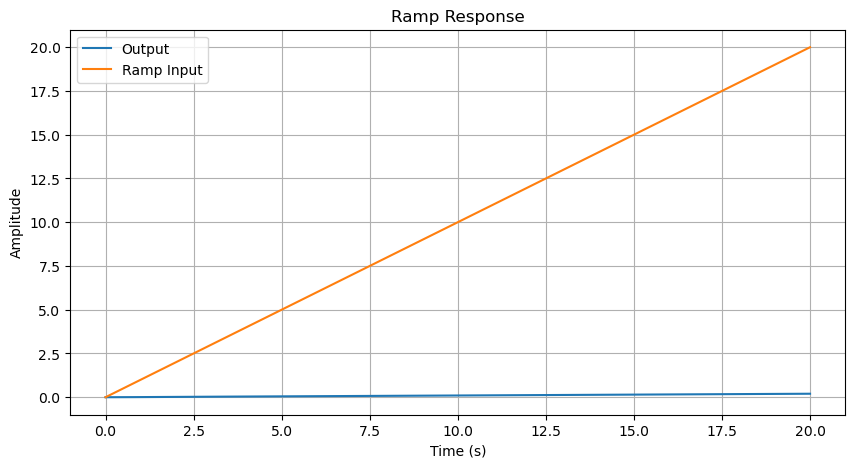

System type: 0
Numerator coefficients: [50.]
Denominator coefficients: [ 10.   8. 100.]

STATIC ERROR CONSTANTS
Kp = 0.49999999599999956
Kv = 4.999999959999995e-08
Ka = 4.9999999599999945e-15

STEADY-STATE ERRORS
Step input error: 0.6666666684444446
Ramp input error: 20000000.160000023
Parabolic input error: inf


In [12]:
if HAS_CONTROL:

    # Plant and loop transfer function
    G = ct.tf(
        [1],
        [10, 8, 100]
    )

    L = 50 * G

    # -------------------------------------------------
    # Ramp response
    # -------------------------------------------------
    t = np.linspace(
        0,
        20,
        2000
    )

    u = t

    tr, yr = ct.forced_response(
        G,
        T=t,
        U=u
    )

    plt.figure(
        figsize=(10, 5)
    )

    plt.plot(
        tr,
        yr,
        label="Output"
    )

    plt.plot(
        t,
        u,
        label="Ramp Input"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.title(
        "Ramp Response"
    )

    plt.grid(True)
    plt.legend()

    plt.show()

    # -------------------------------------------------
    # System type
    # -------------------------------------------------
    poles = ct.poles(L)

    system_type = sum(
        abs(p) < 1e-8
        for p in poles
    )

    print(
        "System type:",
        system_type
    )

    # -------------------------------------------------
    # Extract numerator and denominator correctly
    # -------------------------------------------------
    num = np.asarray(
        L.num[0][0],
        dtype=float
    )

    den = np.asarray(
        L.den[0][0],
        dtype=float
    )

    print(
        "Numerator coefficients:",
        num
    )

    print(
        "Denominator coefficients:",
        den
    )

    # -------------------------------------------------
    # Static error constants
    # -------------------------------------------------

    # Very small positive value approximates s -> 0
    s = 1e-7

    L_at_zero = (
        np.polyval(num, s)
        /
        np.polyval(den, s)
    )

    Kp_static = L_at_zero

    Kv_static = (
        s
        * L_at_zero
    )

    Ka_static = (
        s**2
        * L_at_zero
    )

    print(
        "\nSTATIC ERROR CONSTANTS"
    )

    print(
        "Kp =",
        Kp_static
    )

    print(
        "Kv =",
        Kv_static
    )

    print(
        "Ka =",
        Ka_static
    )

    # -------------------------------------------------
    # Steady-state errors
    # -------------------------------------------------

    ess_step = (
        1
        / (1 + Kp_static)
    )

    ess_ramp = (
        np.inf
        if abs(Kv_static) < 1e-10
        else 1 / Kv_static
    )

    ess_parabolic = (
        np.inf
        if abs(Ka_static) < 1e-10
        else 1 / Ka_static
    )

    print(
        "\nSTEADY-STATE ERRORS"
    )

    print(
        "Step input error:",
        ess_step
    )

    print(
        "Ramp input error:",
        ess_ramp
    )

    print(
        "Parabolic input error:",
        ess_parabolic
    )

else:

    print(
        "python-control is not available."
    )

## Routh–Hurwitz

In [13]:
R,changes=routh_table([1,6,11,6])
print(R); print("Right-half-plane roots:",changes)

[[ 1. 11.]
 [ 6.  6.]
 [10.  0.]
 [ 6.  0.]]
Right-half-plane roots: 0


## Lead, lag and lead–lag compensation

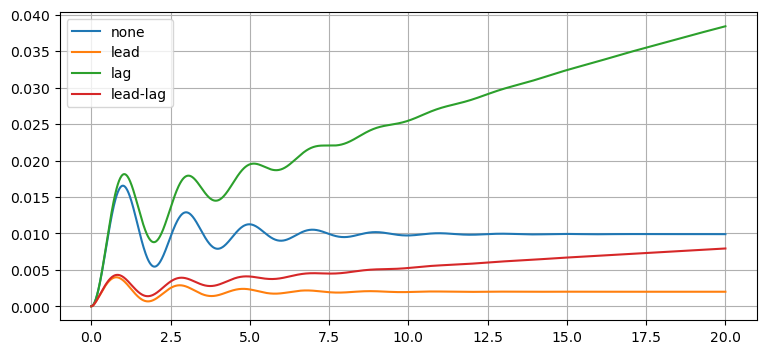

In [14]:
if HAS_CONTROL:
    G=ct.tf([1],[10,8,100])
    lead=ct.tf([1,3],[1,15]); lag=ct.tf([1,.2],[1,.02])
    systems={"none":G,"lead":lead*G,"lag":lag*G,"lead-lag":lead*lag*G}
    t=np.linspace(0,20,1600); plt.figure(figsize=(9,4))
    for n,L in systems.items():
        tt,y=ct.step_response(ct.feedback(L,1),T=t); plt.plot(tt,y,label=n)
    plt.grid(True); plt.legend(); plt.show()

## PID variants, derivative filtering and anti-windup

In [15]:
def pid_aw(Kp=300,Ki=60,Kd=40,N=20,sat=150,aw=5):
    m,b,k=10,8,100; ref=1
    def f(t,y):
        x,v,I,df=y; e=ref-x
        ddf=N*(-v-df)
        uraw=Kp*e+Ki*I+Kd*df; u=np.clip(uraw,-sat,sat)
        return [v,(u-b*v-k*x)/m,e+aw*(u-uraw)/max(sat,1),ddf]
    t=np.linspace(0,10,2000); sol=solve_ivp(f,[0,10],[0,0,0,0],t_eval=t)
    plt.figure(figsize=(9,4)); plt.plot(t,sol.y[0]); plt.axhline(ref,ls="--"); plt.grid(True); plt.show()
widgets.interact(pid_aw,
    Kp=widgets.FloatSlider(value=300,min=0,max=1000,step=10),
    Ki=widgets.FloatSlider(value=60,min=0,max=500,step=5),
    Kd=widgets.FloatSlider(value=40,min=0,max=300,step=5),
    N=widgets.FloatSlider(value=20,min=1,max=100,step=1),
    sat=widgets.FloatSlider(value=150,min=20,max=500,step=10),
    aw=widgets.FloatSlider(value=5,min=0,max=20,step=.5));

interactive(children=(FloatSlider(value=300.0, description='Kp', max=1000.0, step=10.0), FloatSlider(value=60.…

## Feedforward, cascade, disturbance rejection, sensitivity and loop shaping

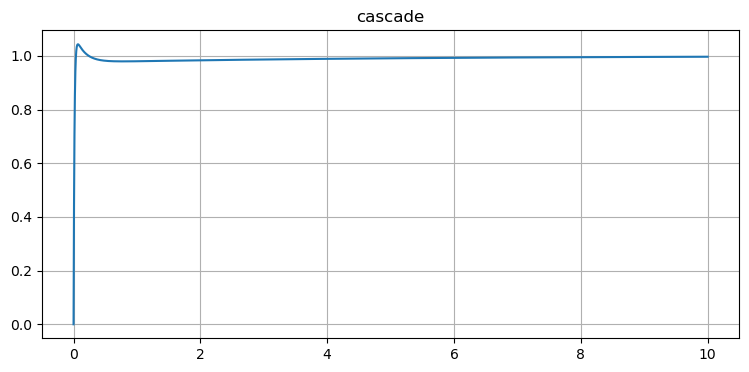

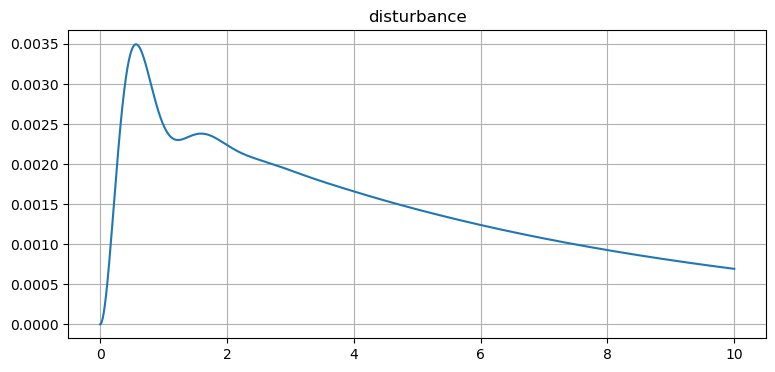

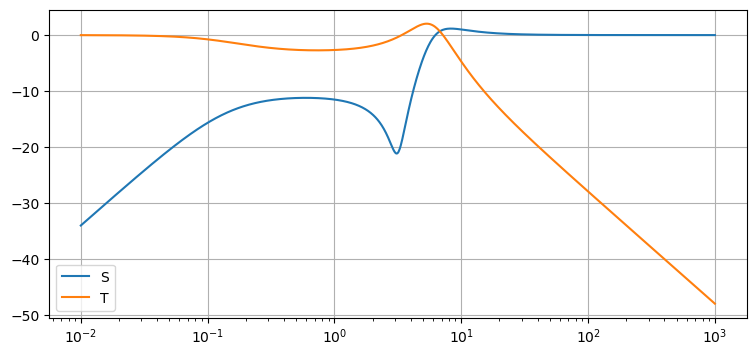

Peak sensitivity: 1.143037047010656


In [16]:
if HAS_CONTROL:
    G=ct.tf([1],[10,8,100]); C=ct.tf([40,250,50],[1,0])
    inner=ct.feedback(20*G,1); cascade=ct.feedback(C*inner,1)
    L=C*G; S=1/(1+L); T=L/(1+L); Td=G*S
    t=np.linspace(0,10,1400)
    for name,sys in [("cascade",cascade),("disturbance",Td)]:
        tt,y=ct.step_response(sys,T=t); plt.figure(figsize=(9,4)); plt.plot(tt,y); plt.grid(True); plt.title(name); plt.show()
    w=np.logspace(-2,3,1200)
    Sr=ct.frequency_response(S,w).frdata.squeeze(); Tr=ct.frequency_response(T,w).frdata.squeeze()
    plt.figure(figsize=(9,4)); plt.semilogx(w,20*np.log10(abs(Sr)),label="S"); plt.semilogx(w,20*np.log10(abs(Tr)),label="T"); plt.grid(True); plt.legend(); plt.show()
    print("Peak sensitivity:",np.max(abs(Sr)))

## Robust parameter uncertainty sweep

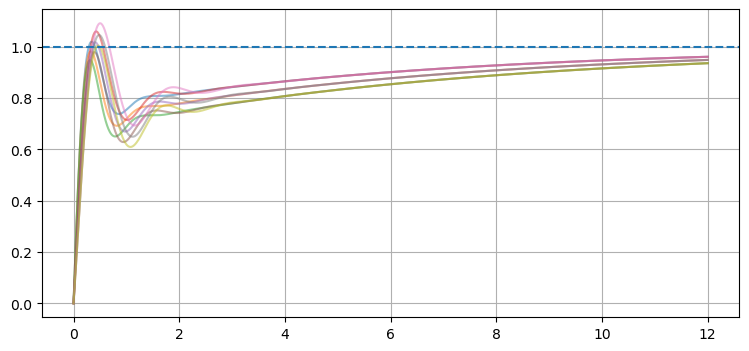

In [17]:
if HAS_CONTROL:
    C=ct.tf([40,250,50],[1,0]); t=np.linspace(0,12,1400)
    plt.figure(figsize=(9,4))
    for m in [7,10,13]:
        for k in [80,100,120]:
            T=ct.feedback(C*ct.tf([1],[m,8,k]),1); tt,y=ct.step_response(T,T=t); plt.plot(tt,y,alpha=.5)
    plt.axhline(1,ls="--"); plt.grid(True); plt.show()

## Controllability, observability, canonical representation and minimal realization

In [18]:
if HAS_CONTROL:
    A=np.array([[0,1],[-10,-.8]]); B=np.array([[0],[.1]]); C=np.array([[1,0]])
    print("Ctrb rank:",np.linalg.matrix_rank(ct.ctrb(A,B)))
    print("Obsv rank:",np.linalg.matrix_rank(ct.obsv(A,C)))
    try: print(ct.minreal(ct.ss(A,B,C,0)))
    except Exception as e: print(e)
    Ac,Bc,Cc,Dc=signal.tf2ss([1],[10,8,100]); print("Canonical-style A:\n",Ac)

Ctrb rank: 2
Obsv rank: 2
minreal requires slycot tb01pd
Canonical-style A:
 [[ -0.8 -10. ]
 [  1.    0. ]]


## State feedback, Nbar, observer and separation principle

In [19]:
if HAS_CONTROL:
    A=np.array([[0,1],[-10,-.8]]); B=np.array([[0],[.1]]); C=np.array([[1,0]])
    K=ct.place(A,B,[-3,-4]); Acl=A-B@K
    Nbar=float(-1/(C@np.linalg.inv(Acl)@B))
    Lobs=ct.place(A.T,C.T,[-8,-10]).T
    print("K:",K); print("Nbar:",Nbar); print("Observer L:",Lobs)
    print("Controller poles:",np.linalg.eigvals(Acl))
    print("Observer poles:",np.linalg.eigvals(A-Lobs@C))

K: [[20. 62.]]
Nbar: 119.99999999999993
Observer L: [[17.2 ]
 [56.24]]
Controller poles: [-3. -4.]
Observer poles: [-10.  -8.]


C:\Users\NSSF\AppData\Local\Temp\ipykernel_1656\1911877862.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Nbar=float(-1/(C@np.linalg.inv(Acl)@B))


## LQR, Kalman filter and LQG

In [20]:
if HAS_CONTROL:
    A=np.array([[0,1],[-10,-.8]]); B=np.array([[0],[.1]]); C=np.array([[1,0]])
    K,S,E=ct.lqr(A,B,np.diag([20,1]),np.array([[1]]))
    print("LQR K:",K); print("LQR poles:",E)
    try:
        Lk,P,Ek=ct.lqe(A,np.eye(2),C,np.diag([.02,.05]),np.array([[.01]]))
        print("Kalman gain:",Lk); print("Estimator poles:",Ek); print("LQG = LQR + Kalman estimator")
    except Exception as e: print(e)

LQR K: [[0.09995005 0.18529175]]
LQR poles: [-0.40926459+3.13727549j -0.40926459-3.13727549j]
Kalman gain: [[ 1.0051145 ]
 [-0.49487242]]
Estimator poles: [-0.90255725+3.08133244j -0.90255725-3.08133244j]
LQG = LQR + Kalman estimator


## Digital control, ZOH, unit circle, Jury and discrete PID

In [ ]:
if HAS_CONTROL:
    G=ct.tf([1],[10,8,100]); Ts=.05; Gd=ct.sample_system(G,Ts,'zoh')
    dp=ct.poles(Gd); print(Gd); print("Discrete poles:",dp); print("Unit-circle stable?",np.all(abs(dp)<1))
    den=np.squeeze(Gd.den)
    if len(den)==3: print(jury_second_order(den))

def discrete_pid(Kp=5,Ki=1,Kd=.1,Ts=.05):
    A=np.array([[0,1],[-10,-.8]]); B=np.array([[0],[.1]]); C=np.array([[1,0]])
    Ad,Bd,_,_,_=signal.cont2discrete((A,B,C,0),Ts)
    x=np.zeros((2,1)); I=0; ep=0; ys=[]
    for n in range(400):
        y=float(C@x); e=1-y; I+=e*Ts; d=(e-ep)/Ts
        u=Kp*e+Ki*I+Kd*d; x=Ad@x+Bd*u; ys.append(float(C@x)); ep=e
    plt.figure(figsize=(9,4)); plt.plot(np.arange(len(ys))*Ts,ys); plt.axhline(1,ls="--"); plt.grid(True); plt.show()
widgets.interact(discrete_pid,Kp=(0.,50.,.5),Ki=(0.,20.,.2),Kd=(0.,5.,.05),Ts=(.005,.2,.005));

<TransferFunction>: sys[120]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0001231 z + 0.0001215
  -----------------------
  z^2 - 1.936 z + 0.9608
Discrete poles: [0.96816693+0.1531086j 0.96816693-0.1531086j]
Unit-circle stable? True
({'|a2|<a0': True, 'P(1)>0': True, 'P(-1)>0': True}, True)


interactive(children=(FloatSlider(value=5.0, description='Kp', max=50.0, step=0.5), FloatSlider(value=1.0, des…

## Nonlinear phase plane: friction, deadband, backlash and saturation

In [22]:
def nonlinear_phase(friction=5,backlash=.02,sat=150):
    m,b,k=10,8,100; F=80
    def f(t,y):
        x,v=y; xe=0 if abs(x)<backlash else np.sign(x)*(abs(x)-backlash)
        u=np.clip(F,-sat,sat); Fc=friction*np.tanh(100*v)
        return [v,(u-b*v-k*xe-Fc)/m]
    plt.figure(figsize=(7,5))
    for y0 in [[-1,0],[-.5,1],[0,1],[.5,-1],[1,0]]:
        sol=solve_ivp(f,[0,10],y0,t_eval=np.linspace(0,10,1200)); plt.plot(sol.y[0],sol.y[1])
    plt.grid(True); plt.xlabel("x"); plt.ylabel("v"); plt.show()
    J=np.array([[0,1],[-k/m,-(b+100*friction)/m]]); print("Jacobian:",J); print("Local poles:",np.linalg.eigvals(J))
widgets.interact(nonlinear_phase,friction=(0.,20.,1.),backlash=(0.,.2,.01),sat=(20.,300.,10.));

interactive(children=(FloatSlider(value=5.0, description='friction', max=20.0, step=1.0), FloatSlider(value=0.…

## Rotational systems, gear reflected inertia and modal analysis

In [23]:
J=.08; B=.12; Kt=3.5
if HAS_CONTROL:
    Grot=ct.tf([1],[J,B,Kt]); print(Grot)
for N in [.5,1,2,5]:
    print("Gear ratio",N,"reflected inertia",J+.2/N**2)

M=np.diag([5,3]); K=np.array([[130,-50],[-50,110]])
w2,phi=la.eig(K,M); wn=np.sqrt(np.real(w2)); idx=np.argsort(wn)
print("Natural frequencies:",wn[idx]); print("Mode shapes:\n",phi[:,idx])

<TransferFunction>: sys[122]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             1
  -----------------------
  0.08 s^2 + 0.12 s + 3.5
Gear ratio 0.5 reflected inertia 0.88
Gear ratio 1 reflected inertia 0.28
Gear ratio 2 reflected inertia 0.13
Gear ratio 5 reflected inertia 0.088
Natural frequencies: [4.16714716 6.73064271]
Mode shapes:
 [[ 0.75687838 -0.46001943]
 [ 0.65355575  0.88790885]]
